<a href="https://colab.research.google.com/github/ArdhanFah/PCVK/blob/main/latihan_integrasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**D2. Pengenalan Python untuk membaca dan menampilkan image dengan pengenalan macam-macam Library (Numpy, pandas, cv2, skimage, PIL dan matplotlib)**

**Langkah (Step) 1**

Pada code awal, beberapa library yang akan digunakan adalah: **numpy, pandas, cv2, skimage, PIL, matplotlib**

* **Numpy** adalah library manipulasi array yang digunakan untuk aljabar linear, transformasi Fourier, dan kemampuan pembangkitan angka acak.

* **Pandas** adalah library untuk manipulasi data dan analisis data.

* **CV2** adalah library untuk tugas-tugas computer vision.

* **Skimage** adalah library yang mendukung aplikasi pengolahan citra (image processing) di Python.

* **Matplotlib** adalah library yang menghasilkan figur visualisasi dan menyediakan toolkit antarmuka grafis (GUI).

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

**Langkah (Step) 2:**

Baca Image dari URLs - Read Image From URLs

Pada Langkah ini kita akan membaca image dari URLs, menampilkannya menggunakan OpenCV, perhatikan ada perbedaan ketika membuka image dalam RGB dan BGR. Channel Warna default untuk OpenCV adalah BGR.

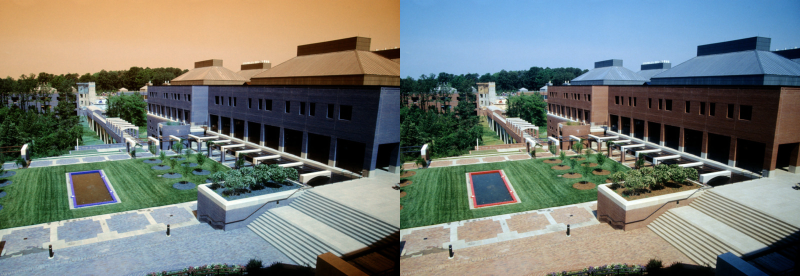

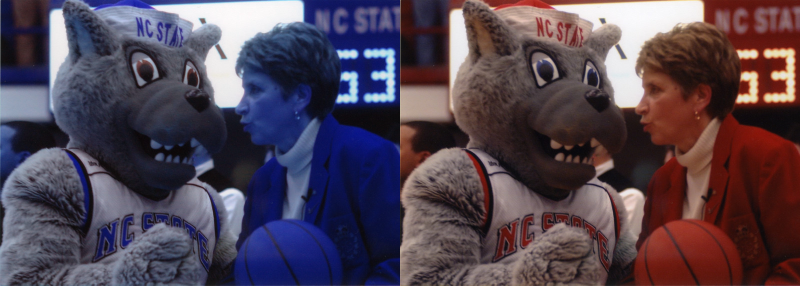



Gagal memuat https://placekitten.com/800/571: HTTP Error 521: <none>



In [ ]:
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://placekitten.com/800/571"]

for url in urls:
  try:
    image = io.imread(url)
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    final_frame = cv.hconcat((image, image_2))
    cv2_imshow(final_frame)
    print('\n')
  except Exception as e:
    print(f"Gagal memuat {url}: {e}\n")

**Langkahh (Step) 3**

melihat ukuran File image

resolusi image: tinggi  x lebar =  286  x  3


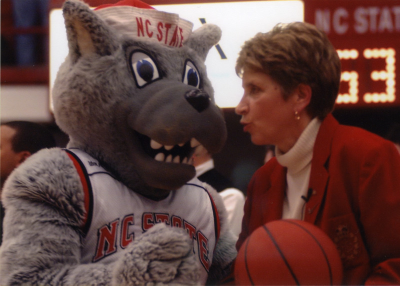

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi  x lebar = ",tinggi, " x ", lebar)
cv2_imshow(image_2)

**Langkah (Step) 4**

mengakses pixel dengan memberi garis diagonal menyilang


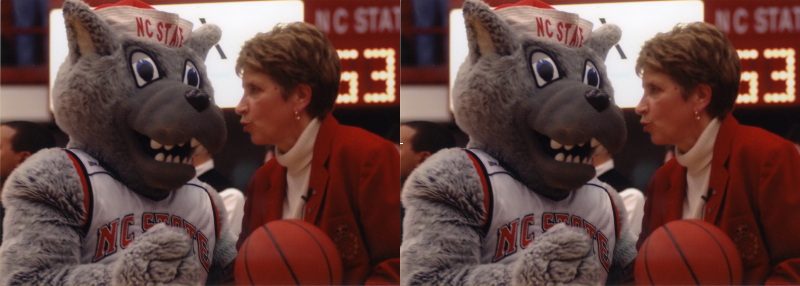

In [ ]:
image_0 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_1 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

#membuat garis horizontal ditengah image
for y in range (lebar):
  image_1[int((tinggi)/2), y] = [255,255,255]

final_frame = cv.hconcat((image_0, image_1))
cv2_imshow(final_frame)

**Tugas Praktikum D2**

Buat garis vertikal dan garis menyilang diagonal pada image keluaran

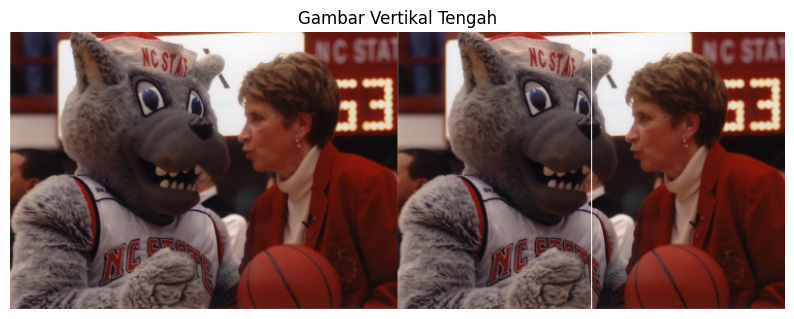

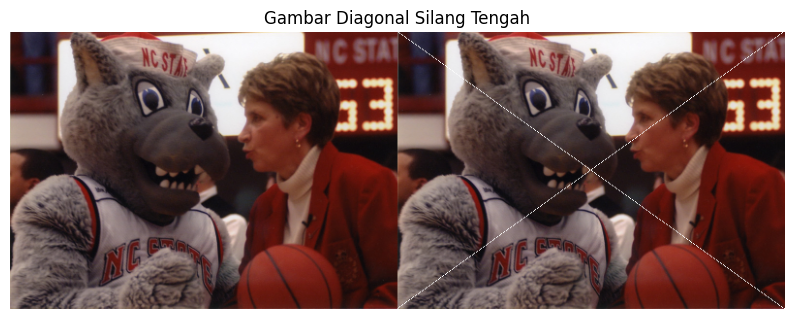

In [41]:
base = image.copy()
h, w, c = base.shape

img_vert = base.copy()
img_diag = base.copy()

mid_x = w // 2
for x in range(h):
  img_vert[x, int(w / 2)] = [255, 255, 255]

for y in range(min(h, w)):
  x1 = int(y * (w - 1) / (h - 1))
  x2 = int((h - 1 - y) * (w - 1) / (h - 1))

  img_diag[y, x1] = [255, 255, 255]
  img_diag[y, x2] = [255, 255, 255]

pair_vert = cv.hconcat([image, img_vert])
pair_diag = cv.hconcat([image, img_diag])

plt.figure(figsize=(10, 5))
plt.imshow(pair_vert)
plt.title("Gambar Vertikal Tengah")
plt.axis("off")
plt.show()

## SILANG
plt.figure(figsize=(10, 5))
plt.imshow(pair_diag)
plt.title("Gambar Diagonal Silang Tengah")
plt.axis("off")
plt.show()

3. Buat garis horisontal berwarna putih dibagian tengah gambar dengan
panjang tertentu


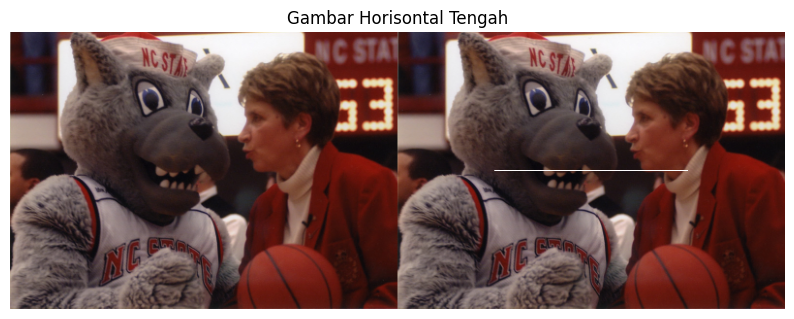

In [46]:
img_horiz = base.copy()
line = 200
mid_y = h // 2

x_start = max(0, (w - line) // 2)
x_end = min(w, (w + line) // 2)

for x in range(x_start, x_end):
    img_horiz[mid_y, x] = [255, 255, 255]


pair_horiz = cv.hconcat([image, img_horiz])

plt.figure(figsize=(10, 5))
plt.imshow(pair_horiz)
plt.title("Gambar Horisontal Tengah")
plt.axis("off")
plt.show()


4. Buat kotak menggunakan kumpulan pixel warna putih di sembarang tempat
dalam gambar

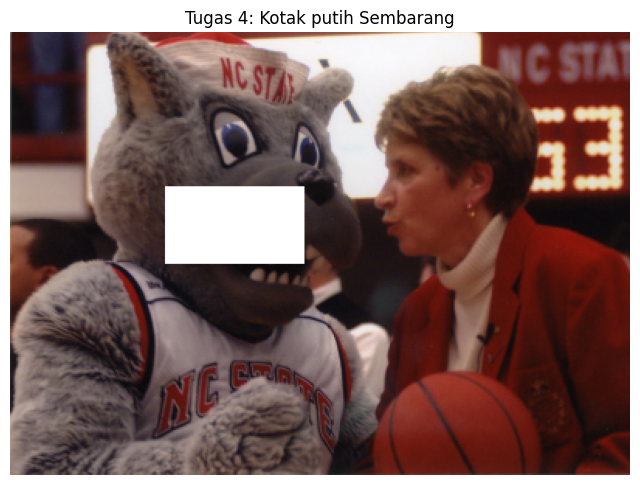

In [51]:
img_rand = base.copy()
img_rand[100:150, 100:190] = [255, 255, 255]

plt.figure(figsize=(8, 8))
plt.imshow(img_rand)
plt.title("Tugas 4: Kotak putih Sembarang")
plt.axis("off")
plt.show()